# 02 — Feature Engineering

## Purpose
This notebook transforms the cleaned dataset (`processed_churn.csv`) into a fully model-ready feature set (`featured_churn.csv`).


---

## Design Philosophy

| Feature Type | Strategy | Reason |
|---|---|---|
| Binary categoricals (Yes/No) | Label encode → 0/1 | Simple, interpretable, no dimensionality cost |
| Contract type | Ordinal encode (0, 1, 2) | Has natural commitment order confirmed by H1 |
| Payment method | One-hot + AutoPay flag | H2 showed behavioral lock-in matters; flag captures it directly |
| Multi-class categoricals | One-hot (drop_first=True) | Avoids false ordinal assumptions; drop_first avoids multicollinearity |
| Numerical features | StandardScaler | Logistic regression is magnitude-sensitive; scaling ensures fair contribution |

---

## 1. Imports and Data Loading

In [9]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from feature_engineering import (
    encode_binary_columns,
    encode_contract_type,
    encode_payment_method,
    encode_multiclass_columns,
    scale_numerical_features,
    BINARY_COLS,
    NUMERICAL_COLS,
)

df = pd.read_csv('../data/processed_churn.csv')

print('Loaded processed data.')
print('Shape:', df.shape)
df.head(3)

Loaded processed data.
Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


---
## 2. Binary Column Encoding

Columns with only `Yes/No` or `Male/Female` values are label-encoded as `1/0`.  
This keeps the dataset compact and interpretable — no extra columns needed.

In [10]:
df_step1 = encode_binary_columns(df)

print('Binary columns encoded:')
for col in BINARY_COLS:
    if col in df_step1.columns:
        print(f'  {col}: {df_step1[col].unique().tolist()}')

Binary columns encoded:
  gender: [1, 0]
  Partner: [1, 0]
  Dependents: [0, 1]
  PhoneService: [0, 1]
  PaperlessBilling: [1, 0]


---
## 3. Contract Type — Ordinal Encoding (Hypothesis H1)

**Why ordinal, not one-hot?**  
Contract type has a meaningful natural order:  
`Month-to-month (0)` → `One year (1)` → `Two year (2)`  

This encodes commitment level directly. Our EDA confirmed this order aligns with decreasing churn rates (42.7% → 11.3% → 2.8%), making ordinal encoding the most honest representation.

Contract encoding:
Contract
0           3875
1           1472
2           1685
Name: count, dtype: int64


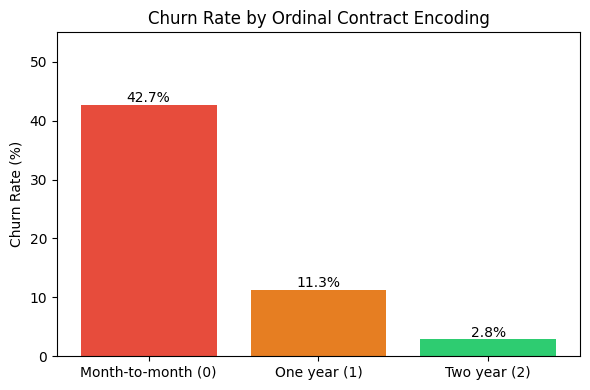


Ordinal encoding correctly captures the commitment gradient.


In [11]:
df_step2 = encode_contract_type(df_step1)

print('Contract encoding:')
print(df_step2[['Contract']].value_counts().sort_index())

# Visualize churn rate by encoded contract value
contract_churn = df_step2.groupby('Contract')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Month-to-month (0)', 'One year (1)', 'Two year (2)'],
    contract_churn.values,
    color=['#e74c3c', '#e67e22', '#2ecc71']
)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Ordinal Contract Encoding')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

print('\nOrdinal encoding correctly captures the commitment gradient.')

---
## 4. Payment Method — One-Hot + AutoPay Flag (Hypothesis H2)

**Two things happen here:**

1. A new binary feature `PaymentMethod_AutoPay` is created:  
   - `1` = automated payment (Bank transfer, Credit card)  
   - `0` = non-automated (Electronic check, Mailed check)  
   
   This directly operationalizes the **behavioral lock-in** concept from H2.

2. The original `PaymentMethod` column is one-hot encoded to preserve granularity — because our EDA showed electronic check (45.3%) behaves very differently from mailed check (19.2%), even though both are non-automated.

Churn rate by AutoPay flag:
  Non-automated (0): 34.7%
  Automated     (1): 16.0%


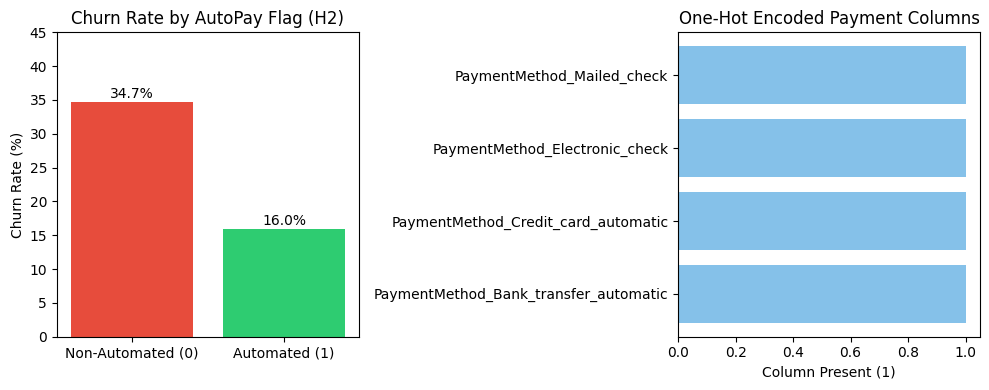


Payment method columns now in dataset:
['PaymentMethod_AutoPay', 'PaymentMethod_Bank_transfer_automatic', 'PaymentMethod_Credit_card_automatic', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check']


In [12]:
df_step3 = encode_payment_method(df_step2)

# Show AutoPay flag distribution
autopay_churn = df_step3.groupby('PaymentMethod_AutoPay')['Churn'].mean() * 100
print('Churn rate by AutoPay flag:')
print(f'  Non-automated (0): {autopay_churn[0]:.1f}%')
print(f'  Automated     (1): {autopay_churn[1]:.1f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# AutoPay flag
axes[0].bar(['Non-Automated (0)', 'Automated (1)'],
            autopay_churn.values,
            color=['#e74c3c', '#2ecc71'])
for i, val in enumerate(autopay_churn.values):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by AutoPay Flag (H2)')
axes[0].set_ylim(0, 45)

# New payment dummy columns
pay_cols = [c for c in df_step3.columns if c.startswith('PaymentMethod_') and c != 'PaymentMethod_AutoPay']
axes[1].barh(pay_cols, [1]*len(pay_cols), color='#3498db', alpha=0.6)
axes[1].set_title('One-Hot Encoded Payment Columns')
axes[1].set_xlabel('Column Present (1)')

plt.tight_layout()
plt.show()

print('\nPayment method columns now in dataset:')
print([c for c in df_step3.columns if 'Payment' in c])

---
## 5. Multi-Class Categorical Encoding

Columns like `InternetService`, `MultipleLines`, `OnlineSecurity` etc. each have 3 values.  
These are one-hot encoded with `drop_first=True` to avoid multicollinearity — important for logistic regression.

In [13]:
cols_before = df_step3.shape[1]
df_step4 = encode_multiclass_columns(df_step3)
cols_after = df_step4.shape[1]

print(f'Columns before multi-class encoding: {cols_before}')
print(f'Columns after  multi-class encoding: {cols_after}')
print(f'New columns added: {cols_after - cols_before}')

Columns before multi-class encoding: 24
Columns after  multi-class encoding: 32
New columns added: 8


---
## 6. Scaling Numerical Features

`tenure`, `MonthlyCharges`, and `TotalCharges` are on very different scales.  
StandardScaler transforms each to **mean=0, std=1**.

**Why this matters:** Without scaling, logistic regression would weight `TotalCharges` (values in thousands) far more than `tenure` (values 0–72) simply due to magnitude — not because it's more important.

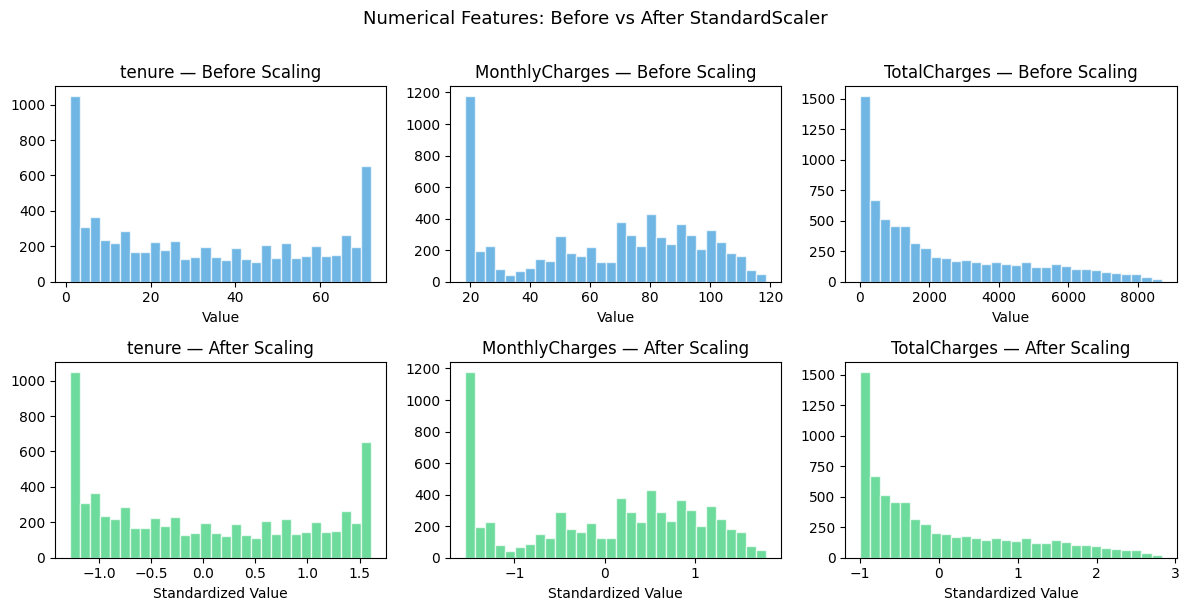

Scaled feature stats (should be ~mean=0, std=1):
      tenure  MonthlyCharges  TotalCharges
mean -0.0000          0.0000       -0.0000
std   1.0001          1.0001        1.0001


In [14]:
# Show distributions before scaling
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, col in enumerate(NUMERICAL_COLS):
    axes[0, i].hist(df_step4[col], bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col} — Before Scaling')
    axes[0, i].set_xlabel('Value')

df_step5, scaler = scale_numerical_features(df_step4)

for i, col in enumerate(NUMERICAL_COLS):
    axes[1, i].hist(df_step5[col], bins=30, color='#2ecc71', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{col} — After Scaling')
    axes[1, i].set_xlabel('Standardized Value')

plt.suptitle('Numerical Features: Before vs After StandardScaler', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Scaled feature stats (should be ~mean=0, std=1):')
print(df_step5[NUMERICAL_COLS].describe().loc[['mean', 'std']].round(4))

---
## 7. Final Dataset Summary

In [15]:
df_final = df_step5

print('=' * 50)
print('FEATURE ENGINEERING COMPLETE')
print('=' * 50)
print(f'Final shape: {df_final.shape}')
print(f'Total features: {df_final.shape[1] - 1}  (excluding target)')
print(f'Target (Churn) balance: {df_final["Churn"].value_counts().to_dict()}')
print(f'Churn rate: {df_final["Churn"].mean()*100:.1f}%')
print()
print('All columns:')
for col in df_final.columns:
    print(f'  {col}')

FEATURE ENGINEERING COMPLETE
Final shape: (7032, 32)
Total features: 31  (excluding target)
Target (Churn) balance: {0: 5163, 1: 1869}
Churn rate: 26.6%

All columns:
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  Contract
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  Churn
  PaymentMethod_AutoPay
  PaymentMethod_Bank_transfer_automatic
  PaymentMethod_Credit_card_automatic
  PaymentMethod_Electronic_check
  PaymentMethod_Mailed_check
  MultipleLines_No_phone_service
  MultipleLines_Yes
  InternetService_Fiber_optic
  InternetService_No
  OnlineSecurity_No_internet_service
  OnlineSecurity_Yes
  OnlineBackup_No_internet_service
  OnlineBackup_Yes
  DeviceProtection_No_internet_service
  DeviceProtection_Yes
  TechSupport_No_internet_service
  TechSupport_Yes
  StreamingTV_No_internet_service
  StreamingTV_Yes
  StreamingMovies_No_internet_service
  StreamingMovies_Yes


---
## 8. Save Featured Dataset

In [16]:
output_path = '../data/featured_churn.csv'
df_final.to_csv(output_path, index=False)

print(f'Saved to: {output_path}')
print('Ready for modeling (03_modeling.ipynb)')

Saved to: ../data/featured_churn.csv
Ready for modeling (03_modeling.ipynb)


---
## Summary of Engineering Decisions

| Column | Strategy | Rationale |
|---|---|---|
| gender, Partner, Dependents, PhoneService, PaperlessBilling | Label encode 0/1 | Binary — no ordering needed |
| Contract | Ordinal encode 0/1/2 | Natural commitment order confirmed by H1 |
| PaymentMethod | One-hot + AutoPay flag | H2 behavioral lock-in concept + granularity |
| MultipleLines, InternetService, etc. | One-hot (drop_first) | No ordinal relationship; avoid multicollinearity |
| tenure, MonthlyCharges, TotalCharges | StandardScaler | Magnitude normalization for logistic regression |

